# Анализ Turbovec для семантической кластеризации

Пайплайн анализа:
1. Загрузка результатов бенчмарка (baseline и turbovec bw=2, 4; k=5, 10, dim=512)
2. Объединение всех прогонов в общую таблицу
3. Для каждой конфигурации (k, bit_width) усреднить по-запросные метрики и провизуализировать (line chart):
- kNN accuracy (класс запроса угадан по большинству соседей)
- Same-class recall@k (доля соседей того же класса в топ-k)
- MRR (обратный ранг первого соседа того же класса)
4. Бутстрап доверительных интервалов для парной разницы средних
5. McNemar тест по бинарным исходам
6. Forest plot (главный график со сводной информацией)

In [2]:
# Утилиты
from pathlib import Path
import re
import json
RESULTS_DIR = str(Path.cwd().parent / "results/semantic_clustering")
RESULTS_DIR = RESULTS_DIR.replace('\\', '/') + "/"

In [3]:
# Библиотеки для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

## 1. Загрузка данных выборочно

In [4]:
tv_bw2_k5 = pd.read_csv(RESULTS_DIR + 'turbovec_bw2_dim512_k5_20260712_165403.csv')
bl_k10 = pd.read_csv(RESULTS_DIR + 'baseline_dim512_k10_20260712_214840.csv')

In [5]:
tv_bw2_k5.head()

,query_idx,query_text_preview,true_label,true_category,knn_accuracy,same_class_recall,first_same_class_rank,query_time_ms
0,0,I am a little confused on all of the models of...,7,rec.autos,0.0,0.4,3.0,27.4934
1,1,I'm not familiar at all with the format of the...,5,comp.windows.x,1.0,0.8,1.0,0.3444
2,2,"In a word, yes.",0,alt.atheism,0.0,0.0,NaN,0.2644
3,3,They were attacking the Iraqis to drive them ...,17,talk.politics.mideast,1.0,0.4,1.0,0.1577
4,4,I've just spent two solid months arguing that...,19,talk.religion.misc,0.0,0.0,NaN,0.1463


In [6]:
tv_bw2_k5.describe()

,query_idx,true_label,knn_accuracy,same_class_recall,first_same_class_rank,query_time_ms
count,1951.000000,1951.000000,1951.000000,1951.000000,1696.000000,1951.000000
mean,975.000000,9.219375,0.697591,0.592619,1.472288,0.238725
std,563.349507,5.562332,0.459419,0.354931,0.962021,0.680352
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.093000
25%,487.500000,4.000000,0.000000,0.200000,1.000000,0.151300
50%,975.000000,9.000000,1.000000,0.600000,1.000000,0.205400
75%,1462.500000,14.000000,1.000000,1.000000,2.000000,0.273950
max,1950.000000,19.000000,1.000000,1.000000,5.000000,27.493400


## 2. Группировка таблиц

In [7]:
frames = []

for file in Path(RESULTS_DIR).glob("*.csv"):
    name = file.stem

    if name.startswith("baseline"):
        method = "baseline"
        bit_width = np.nan
    else:
        method = "turbovec"
        bit_width = int(re.search(r"bw(\d+)", name).group(1))

    dim = int(re.search(r"dim(\d+)", name).group(1))
    k = int(re.search(r"k(\d+)", name).group(1))

    run_id = name.split("_")[-2] + "_" + name.split("_")[-1]

    df = pd.read_csv(file)

    df["method"] = method
    df["bit_width"] = bit_width
    df["dim"] = dim
    df["k"] = k
    df["run_id"] = run_id

    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

all_df["variant"] = np.where(
    all_df.method=="baseline",
    "baseline",
    "turbovec_bw"+all_df.bit_width.astype("Int64").astype(str)
)

In [8]:
all_df.tail()

,query_idx,query_text_preview,true_label,true_category,knn_accuracy,same_class_recall,first_same_class_rank,query_time_ms,method,bit_width,dim,k,run_id,variant
11701,1946,That's kind of extra work that one cannot exp...,12,sci.electronics,1.0,0.6,1.0,0.2126,turbovec,4.0,512,5,20260712_165403,turbovec_bw4
11702,1947,First the FBI said they saw two members of t...,16,talk.politics.guns,1.0,0.8,1.0,0.2364,turbovec,4.0,512,5,20260712_165403,turbovec_bw4
11703,1948,"As I've noted, you can likely get around that...",11,sci.crypt,0.0,0.2,5.0,0.2333,turbovec,4.0,512,5,20260712_165403,turbovec_bw4
11704,1949,One can only remap special-command keys in pro...,2,comp.os.ms-windows.misc,0.0,0.2,2.0,0.2377,turbovec,4.0,512,5,20260712_165403,turbovec_bw4
11705,1950,In-reply-to: johnn@eskimo.com's message of 21 ...,3,comp.sys.ibm.pc.hardware,1.0,0.2,1.0,0.3099,turbovec,4.0,512,5,20260712_165403,turbovec_bw4


## 3. Вычисление метрик

per-query MRR восстанавливаем как 1/`first_same_class_rank` (0, если соседа того же класса в топ-k нет)

In [9]:
summaries = {}
for f in sorted(Path(RESULTS_DIR).glob("summary_*.json")):
    s = json.loads(f.read_text())
    summaries[s["run_id"]] = s

all_df["mrr"] = np.where(all_df["first_same_class_rank"].notna(),
                         1.0 / all_df["first_same_class_rank"], 0.0)

MAIN_METRICS = ["knn_accuracy", "same_class_recall", "mrr"]

def silhouette_res(run_id, variant):
    s = summaries[run_id]
    if variant == "baseline":
        return s["baseline"]["silhouette_score"]
    bw = int(variant.split("bw")[1])
    return next(t["silhouette_score"] for t in s["turbovec"] if t["bit_width"] == bw)

def compute_metrics(sub):
    run_id = sub["run_id"].iloc[0]
    k = sub["k"].iloc[0]
    bit_width = sub["bit_width"].iloc[0]
    return (run_id, k, bit_width) + tuple(sub[m].mean() for m in MAIN_METRICS)

metrics_df = pd.DataFrame(
    [compute_metrics(sub) + (variant, silhouette_res(run_id, variant))
     for (run_id, k, variant), sub in all_df.groupby(["run_id", "k", "variant"])],
    columns=["run_id", "k", "bit_width"] + MAIN_METRICS + ["variant", "silhouette_global"],
)
metrics_df.round(4)

,run_id,k,bit_width,knn_accuracy,same_class_recall,mrr,variant,silhouette_global
0,20260712_165403,5,NaN,0.6961,0.5917,0.7352,baseline,0.032
1,20260712_165403,5,2.0,0.6976,0.5926,0.7348,turbovec_bw2,0.032
2,20260712_165403,5,4.0,0.6920,0.5891,0.7368,turbovec_bw4,0.032
3,20260712_214840,10,NaN,0.6996,0.5556,0.7417,baseline,0.032
4,20260712_214840,10,2.0,0.7084,0.5562,0.7411,turbovec_bw2,0.032
5,20260712_214840,10,4.0,0.7027,0.5542,0.7439,turbovec_bw4,0.032


### График

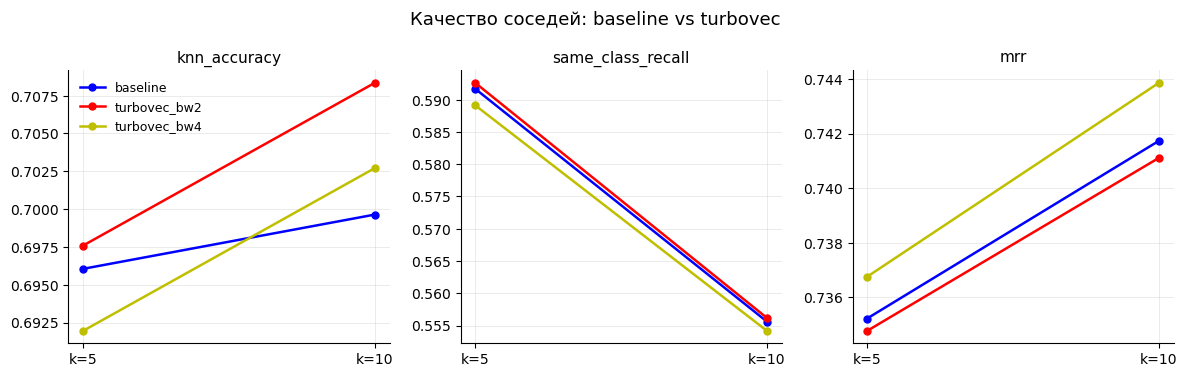

In [10]:
COLORS = {"baseline": "b", "turbovec_bw2": "r", "turbovec_bw4": "y"}

plot_df = metrics_df.sort_values("k").copy()
plot_df["config"] = "k=" + plot_df["k"].astype(str)
order = plot_df["config"].drop_duplicates().tolist()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
for ax, metric in zip(axes, MAIN_METRICS):
    for variant, color in COLORS.items():
        sub = plot_df[plot_df["variant"] == variant].set_index("config").reindex(order)
        ax.plot(order, sub[metric], marker="o", ms=5, lw=1.8, color=color, label=variant)
    ax.set_title(metric, fontsize=11)
    ax.grid(alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Качество соседей: baseline vs turbovec", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Бутстрап доверительных интервалов

In [11]:
def bootstrap_ci(sample, theta_func, alpha=0.05, B=1000, random_state=None, return_samples=False):
    if random_state is not None:
        np.random.seed(random_state)

    N = len(sample)
    theta_estim = theta_func(sample)

    theta_asterisk_array = []
    for _ in range(B):
        bootstrap_sample = np.random.choice(sample, replace=True, size=N)
        theta_asterisk = theta_func(bootstrap_sample)
        theta_asterisk_array.append(theta_asterisk)
    theta_asterisk_array = np.array(theta_asterisk_array)

    left_theta_asterisk, right_theta_asterisk = np.quantile(theta_asterisk_array, [alpha / 2, 1 - alpha / 2])
    left_bound = 2 * theta_estim - right_theta_asterisk
    right_bound = 2 * theta_estim - left_theta_asterisk

    if return_samples:
        return left_bound, right_bound, theta_estim, theta_asterisk_array
    return left_bound, right_bound


def compute_metric_diff_bootstrap(df, run_id, bit_width, metric='knn_accuracy', alpha=0.05, B=1000, random_state=42):
    sub = df[df['run_id'] == run_id]
    baseline = sub[sub['variant'] == 'baseline'][['query_idx', metric]]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['query_idx', metric]]
    paired = baseline.merge(tv, on='query_idx', suffixes=('_baseline', '_turbovec'))

    s_baseline = paired[metric + '_baseline'].values
    s_turbovec = paired[metric + '_turbovec'].values

    def theta_func(idx):
        idx = np.asarray(idx)
        return s_turbovec[idx].mean() - s_baseline[idx].mean()

    sample = np.arange(len(paired))
    ci_low, ci_high, theta_hat, theta_star = bootstrap_ci(
        sample, theta_func, alpha=alpha, B=B, random_state=random_state, return_samples=True
    )

    p_emp = min(2 * min((theta_star > 0).mean(), (theta_star < 0).mean()), 1.0)

    return dict(run_id=run_id, bit_width=bit_width, metric=metric, n=len(paired), n_boot=len(theta_star),
                observed_diff_turbovec_minus_baseline=theta_hat,
                ci95_low=ci_low, ci95_high=ci_high, p_value_empirical=p_emp)

In [12]:
boot_df = pd.DataFrame([
    compute_metric_diff_bootstrap(all_df, run_id, bw, metric=metric)
    for run_id in sorted(all_df["run_id"].unique())
    for bw in (2, 4)
    for metric in MAIN_METRICS
])
boot_df["k"] = boot_df["run_id"].map(lambda r: summaries[r]["k"])
boot_df.round(5)

,run_id,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical,k
0,20260712_165403,2,knn_accuracy,1951,1000,0.00154,-0.00923,0.01128,0.704,5
1,20260712_165403,2,same_class_recall,1951,1000,0.00092,-0.00359,0.00605,0.716,5
2,20260712_165403,2,mrr,1951,1000,-0.00045,-0.00716,0.00654,0.930,5
3,20260712_165403,4,knn_accuracy,1951,1000,-0.00410,-0.01076,0.00205,0.226,5
4,20260712_165403,4,same_class_recall,1951,1000,-0.00256,-0.00523,0.00000,0.054,5
5,20260712_165403,4,mrr,1951,1000,0.00153,-0.00213,0.00530,0.392,5
6,20260712_214840,2,knn_accuracy,1951,1000,0.00871,-0.00205,0.02000,0.120,10
7,20260712_214840,2,same_class_recall,1951,1000,0.00056,-0.00262,0.00379,0.732,10
8,20260712_214840,2,mrr,1951,1000,-0.00062,-0.00736,0.00625,0.888,10
9,20260712_214840,4,knn_accuracy,1951,1000,0.00308,-0.00461,0.01026,0.374,10


## 5. McNemar тест

По двум бинарным исходам на запрос: `knn_accuracy` — верно ли предсказан класс по большинству соседей; `same_class_recall` > 0 — нашёлся ли хотя бы один сосед того же класса в топ-k.

In [13]:
def mcnemar_test(df, run_id, bit_width, metric):
    sub = df[df['run_id'] == run_id]
    baseline = sub[sub['variant'] == 'baseline'][['query_idx', metric]]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['query_idx', metric]]
    paired = baseline.merge(tv, on='query_idx', suffixes=('_baseline', '_turbovec'))

    bl_ok = paired[metric + '_baseline'] > 0
    tv_ok = paired[metric + '_turbovec'] > 0
    table = [[int((bl_ok & tv_ok).sum()), int((bl_ok & ~tv_ok).sum())],
             [int((~bl_ok & tv_ok).sum()), int((~bl_ok & ~tv_ok).sum())]]

    res = mcnemar(table, exact=False, correction=True)
    return dict(run_id=run_id, bit_width=bit_width, metric=metric,
                baseline_only_hit=table[0][1], turbovec_only_hit=table[1][0],
                statistic=res.statistic, p_value=res.pvalue)

mcnemar_df = pd.DataFrame([
    mcnemar_test(all_df, run_id, bw, metric)
    for run_id in sorted(all_df["run_id"].unique())
    for bw in (2, 4)
    for metric in ("knn_accuracy", "same_class_recall")
])
mcnemar_df["k"] = mcnemar_df["run_id"].map(lambda r: summaries[r]["k"])
mcnemar_df.round(4)

,run_id,bit_width,metric,baseline_only_hit,turbovec_only_hit,statistic,p_value,k
0,20260712_165403,2,knn_accuracy,45,48,0.0430,0.8357,5
1,20260712_165403,2,same_class_recall,32,29,0.0656,0.7979,5
2,20260712_165403,4,knn_accuracy,26,18,1.1136,0.2913,5
3,20260712_165403,4,same_class_recall,14,10,0.3750,0.5403,5
4,20260712_214840,2,knn_accuracy,48,65,2.2655,0.1323,10
5,20260712_214840,2,same_class_recall,21,18,0.1026,0.7488,10
6,20260712_214840,4,knn_accuracy,27,33,0.4167,0.5186,10
7,20260712_214840,4,same_class_recall,6,12,1.3889,0.2386,10


## 6. Forest plot

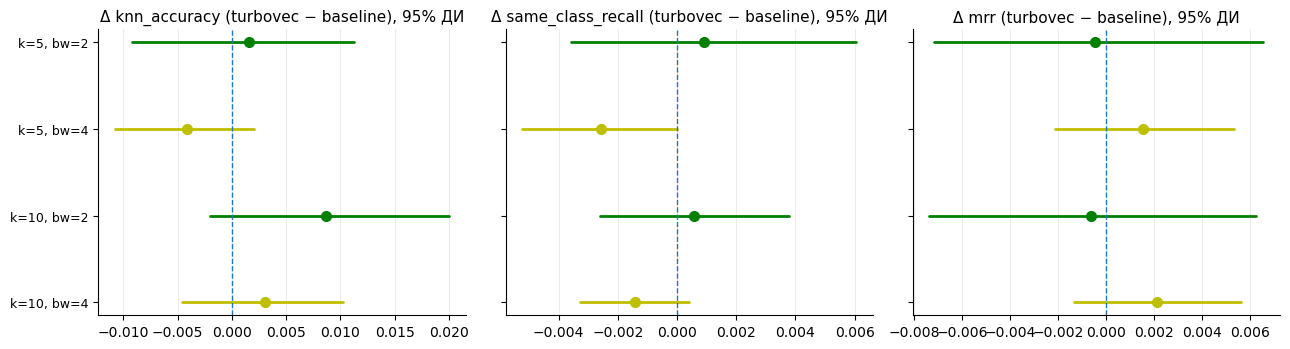

In [14]:
BW_COLORS = {2: "g", 4: "y"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, metric in zip(axes, MAIN_METRICS):
    sub = boot_df[boot_df["metric"] == metric].sort_values(
        ["k", "bit_width"]).reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        color = BW_COLORS[row["bit_width"]]
        ax.plot([row["ci95_low"], row["ci95_high"]], [ypos[i]] * 2,
                color=color, lw=2, solid_capstyle="round")
        ax.plot(row["observed_diff_turbovec_minus_baseline"], ypos[i], "o", ms=7, color=color)
    ax.axvline(0, lw=1, ls="--")
    labels = ("k=" + sub["k"].astype(str) + ", bw=" + sub["bit_width"].astype(str))
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f"Δ {metric} (turbovec − baseline), 95% ДИ", fontsize=11)
    ax.grid(axis="x", alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## Вывод

Тurbovec не ухудшает качество семантической кластеризации (поиска соседей по эмбеддингам 20 Newsgroups), структура соседства сохраняется при обоих bit width.

- Ни одной статистически значимой просадки: все 12 бутстрап-сравнений дают 95% CI, накрывающие ноль; McNemar: 0 значимых различий из 8.
- с turbovec запрос так же часто попадает в свой кластер по большинству соседей (kNN accuracy = 0.69–0.71), доля соседей того же класса в топ-k не меняется (same-class recall = 0.55–0.59).
- Числено bw=2 местами даже выше baseline, но тоже не значимо.